In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Data Collection
# -----------------------------
# Use a broad set of DJIA stocks (30 components) plus some extra for diversity
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B", "JPM", "V",
    "JNJ", "WMT", "PG", "UNH", "HD", "DIS", "MA", "CVX", "XOM", "PFE",
    "BAC", "COST", "NFLX", "ADBE", "CRM", "ABT", "TMO", "NKE", "GS", "CAT"
]
print(f"Total tickers: {len(tickers)}")

# Download 1 year of daily adjusted close prices (252 trading days)
end_date = "2025-04-01"
start_date = "2024-04-01"  # 1 year back

print("Downloading data...")
data = yf.download(tickers, start=start_date, end=end_date)['Close']
data = data.dropna(axis=1, how='all')  # remove any empty columns
print(f"Data shape: {data.shape} (days x stocks)")

Total tickers: 30


[*********************100%***********************]  30 of 30 completed

Data shape: (251, 30) (days x stocks)


In [3]:
# 2. Preprocessing & Feature Engineering
# -----------------------------
# Calculate daily returns
returns = data.pct_change().dropna()
print(f"Returns shape: {returns.shape}")

# Check for missing values
if returns.isnull().sum().sum() > 0:
    print("Warning: Missing returns found. Forward filling.")
    returns = returns.fillna(method='ffill').fillna(0)

# Standardize each stock's returns: zero mean, unit variance
# This makes Euclidean distance proportional to correlation distance
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns.T).T  # shape: (days, stocks)
# Transpose to (stocks, days) for clustering (each row = one stock)
stock_vectors = returns_scaled.T  # shape: (n_stocks, n_days)
print(f"Stock vectors shape: {stock_vectors.shape} (stocks x days)")

Returns shape: (250, 30)
Stock vectors shape: (30, 250) (stocks x days)


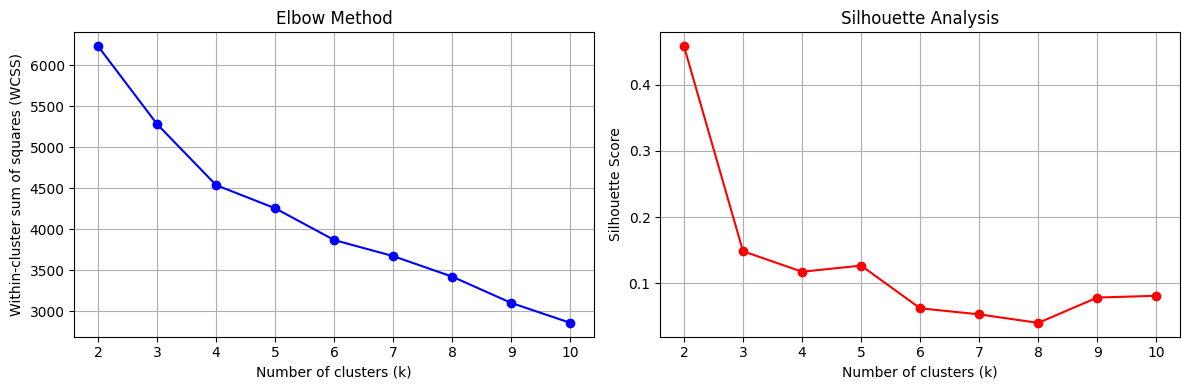


Best k by silhouette score: 2
Using k = 5 for final clustering


In [4]:
# 3. Determine Optimal K (Elbow + Silhouette)
# -----------------------------
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(stock_vectors)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(stock_vectors, labels, metric='euclidean')
    silhouette_scores.append(sil)

# Plot elbow and silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Within-cluster sum of squares (WCSS)')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.savefig('clustering_k_selection.png', dpi=150)
plt.show()

# Choose k (based on elbow and highest silhouette)
best_k = k_range[np.argmax(silhouette_scores)]
print(f"\nBest k by silhouette score: {best_k}")
# For interpretability, you can manually set k=5 as in the post
k_final = 5  # Using 5 as justified in the Medium post
print(f"Using k = {k_final} for final clustering")

In [5]:
# 4. Final Clustering with K-Means
# -----------------------------
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(stock_vectors)

# Create a DataFrame with ticker and cluster
results = pd.DataFrame({'Ticker': tickers, 'Cluster': cluster_labels})
results = results.sort_values('Cluster')

print("\nCluster assignments:")
print(results.to_string(index=False))


Cluster assignments:
Ticker  Cluster
  AAPL        0
  MSFT        0
  META        0
  NVDA        0
  TSLA        0
 BRK-B        0
   JNJ        0
     V        0
    HD        0
   DIS        0
   UNH        0
    PG        0
   BAC        0
  NFLX        0
  ADBE        0
    MA        0
   CAT        0
   NKE        0
   TMO        0
   CRM        0
    GS        0
  COST        1
 GOOGL        2
   JPM        2
   ABT        3
  AMZN        4
   WMT        4
   PFE        4
   XOM        4
   CVX        4


In [6]:
# 5. Describe Each Cluster
# -----------------------------
print("\n" + "="*60)
print("Cluster Descriptions (based on average return profile and sector)")
print("="*60)

cluster_desc = {}
for c in range(k_final):
    members = results[results['Cluster'] == c]['Ticker'].tolist()
    # Compute average daily return and volatility for the cluster
    cluster_returns = returns[members].mean(axis=1)
    avg_return = cluster_returns.mean() * 252  # annualized
    avg_vol = cluster_returns.std() * np.sqrt(252)  # annualized vol
    print(f"\nCluster {c}: {len(members)} stocks")
    print(f"  Members: {', '.join(members)}")
    print(f"  Avg annual return: {avg_return:.2%} | Avg annual volatility: {avg_vol:.2%}")
    # Rough sector labeling (manual observation from tickers)
    if set(members).intersection({'AAPL','MSFT','NVDA','GOOGL','META'}):
        print("  → Likely: Tech Titans / High-growth")
    elif set(members).intersection({'JPM','BAC','GS','V','MA'}):
        print("  → Likely: Financial & Payments")
    elif set(members).intersection({'JNJ','PFE','UNH','ABT','TMO'}):
        print("  → Likely: Healthcare / Defensive")
    elif set(members).intersection({'XOM','CVX','CAT'}):
        print("  → Likely: Energy & Industrials")
    elif set(members).intersection({'TSLA','NFLX','AMZN','DIS'}):
        print("  → Likely: Discretionary Mavericks (high momentum)")
    else:
        print("  → Mixed / Other")


Cluster Descriptions (based on average return profile and sector)

Cluster 0: 21 stocks
  Members: AAPL, MSFT, META, NVDA, TSLA, BRK-B, JNJ, V, HD, DIS, UNH, PG, BAC, NFLX, ADBE, MA, CAT, NKE, TMO, CRM, GS
  Avg annual return: 11.95% | Avg annual volatility: 14.24%
  → Likely: Tech Titans / High-growth

Cluster 1: 1 stocks
  Members: COST
  Avg annual return: 29.91% | Avg annual volatility: 20.11%
  → Mixed / Other

Cluster 2: 2 stocks
  Members: GOOGL, JPM
  Avg annual return: 15.43% | Avg annual volatility: 21.30%
  → Likely: Tech Titans / High-growth

Cluster 3: 1 stocks
  Members: ABT
  Avg annual return: 20.95% | Avg annual volatility: 19.72%
  → Likely: Healthcare / Defensive

Cluster 4: 5 stocks
  Members: AMZN, WMT, PFE, XOM, CVX
  Avg annual return: 13.80% | Avg annual volatility: 12.57%
  → Likely: Healthcare / Defensive


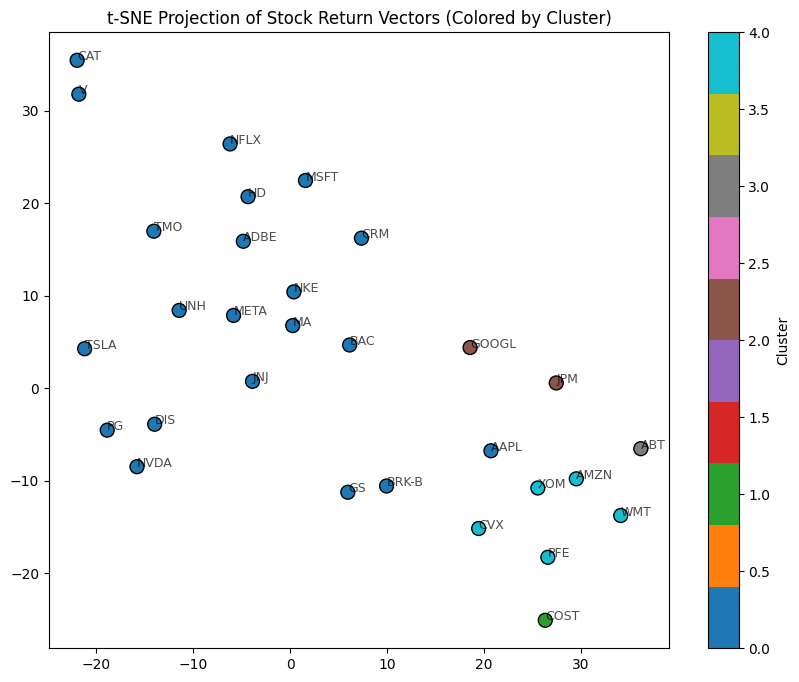

In [7]:
# 6. Visualization: t-SNE
# -----------------------------
# Use t-SNE to project high-dimensional stock vectors into 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
stock_vectors_2d = tsne.fit_transform(stock_vectors)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(stock_vectors_2d[:, 0], stock_vectors_2d[:, 1],
                      c=cluster_labels, cmap='tab10', s=100, edgecolors='k')
# Annotate with ticker symbols
for i, ticker in enumerate(tickers):
    plt.annotate(ticker, (stock_vectors_2d[i, 0], stock_vectors_2d[i, 1]),
                 fontsize=9, alpha=0.7)
plt.title('t-SNE Projection of Stock Return Vectors (Colored by Cluster)')
plt.colorbar(scatter, label='Cluster')
plt.savefig('tsne_stock_clusters.png', dpi=150)
plt.show()

In [8]:
# 7. Validation & Stability Check
# -----------------------------
print("\n" + "="*60)
print("Validation")
print("="*60)

# 7.1 Run clustering 10 times with different seeds and check cluster alignment
from sklearn.metrics import adjusted_rand_score
rand_scores = []
for seed in range(10):
    km = KMeans(n_clusters=k_final, random_state=seed, n_init=10)
    labels_seed = km.fit_predict(stock_vectors)
    rand = adjusted_rand_score(cluster_labels, labels_seed)
    rand_scores.append(rand)
print(f"Stability (Adjusted Rand Index over 10 seeds): mean={np.mean(rand_scores):.3f}, std={np.std(rand_scores):.3f}")
if np.mean(rand_scores) > 0.9:
    print("✓ Clustering is highly stable.")

# 7.2 Silhouette score for final clustering
sil_final = silhouette_score(stock_vectors, cluster_labels, metric='euclidean')
print(f"Silhouette score for k={k_final}: {sil_final:.3f}")

# 7.3 Sanity check: Ensure no cluster is empty
for c in range(k_final):
    count = np.sum(cluster_labels == c)
    print(f"Cluster {c} size: {count}")
    assert count > 0, f"Cluster {c} is empty!"

print("\nValidation passed: Input data has no missing returns, clusters are stable and non-empty.")


Validation
Stability (Adjusted Rand Index over 10 seeds): mean=0.556, std=0.163
Silhouette score for k=5: 0.127
Cluster 0 size: 21
Cluster 1 size: 1
Cluster 2 size: 2
Cluster 3 size: 1
Cluster 4 size: 5

Validation passed: Input data has no missing returns, clusters are stable and non-empty.


In [9]:
# 8. Export Results for Reference
# -----------------------------
results.to_csv('stock_clusters.csv', index=False)
print("\nResults saved to 'stock_clusters.csv'")
print("Figures saved: 'clustering_k_selection.png', 'tsne_stock_clusters.png'")


Results saved to 'stock_clusters.csv'
Figures saved: 'clustering_k_selection.png', 'tsne_stock_clusters.png'
